# Project information

This project focuses on bank fraud detection using machine learning models on credit card transaction data. The goal is to compare how different models perform when trained on separate bank datasets and to evaluate whether augmented data improves fraud detection results. For this project, the dataset was divided into four simulated banks—Bank A, Bank B, Bank C, and Bank D—and multiple models were trained and tested using the same workflow. Performance was evaluated using Precision, Recall, F1 Score, and PR-AUC in order to better measure results on imbalanced fraud data.

##Dataset loading

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
# ********************************
# Load bank datasets
# ********************************

import pandas as pd

# ---- Load normal bank files ----
bank_a = pd.read_csv("bank_a.csv")
bank_b = pd.read_csv("bank_b.csv")
bank_c = pd.read_csv("bank_c.csv")
bank_d = pd.read_csv("bank_d.csv")

# ---- Load augmented bank files ----
bank_a_aug = pd.read_csv("bank_a(augmented).csv")
bank_b_aug = pd.read_csv("bank_b(augmented).csv")
bank_c_aug = pd.read_csv("bank_c(augmented).csv")
bank_d_aug = pd.read_csv("bank_d(augmented).csv")

# ---- Quick check to confirm files loaded ----
print("Normal Bank A shape:", bank_a.shape)
print("Normal Bank B shape:", bank_b.shape)
print("Normal Bank C shape:", bank_c.shape)
print("Normal Bank D shape:", bank_d.shape)

print("\nAugmented Bank A shape:", bank_a_aug.shape)
print("Augmented Bank B shape:", bank_b_aug.shape)
print("Augmented Bank C shape:", bank_c_aug.shape)
print("Augmented Bank D shape:", bank_d_aug.shape)

Normal Bank A shape: (71202, 31)
Normal Bank B shape: (71202, 31)
Normal Bank C shape: (71202, 31)
Normal Bank D shape: (71201, 31)

Augmented Bank A shape: (74639, 31)
Augmented Bank B shape: (74639, 31)
Augmented Bank C shape: (74639, 31)
Augmented Bank D shape: (74638, 31)


# Train/test split for each bank


***Why this matters:*** We train the model on one portion of the bank’s data and evaluate it on unseen data to measure how well it generalizes.

***What it does:*** This section separates each bank’s dataset into features (X) and label (y), then splits the data into training and testing sets.

Data needs to be trained (data model learns from), and tested (unseen data used to check how well/accurate the model performs).

***Important note:*** Because fraud data can be imbalanced, I'll use 'stratify=y' so the fraud/non-fraud proportion stays more consistent in both train and test sets.

In [ ]:
# ********************************
# Train/test split for each bank
# ********************************

from sklearn.model_selection import train_test_split

# ---- Set the label column name ----
# To be changed if dataset uses a different target column name.
label_column = "Class"
# ^ tells notebook which column is the answer the model is trying to predict.
# 0 = non-fraud
# 1 = fraud

# ---- Separate features (X) and label (y) for each normal bank ----
# X = input columns the model learns from
# y = target column the model tries to predict (fraud/ not fraud)

X_a = bank_a.drop(columns=[label_column])
y_a = bank_a[label_column]

X_b = bank_b.drop(columns=[label_column])
y_b = bank_b[label_column]

X_c = bank_c.drop(columns=[label_column])
y_c = bank_c[label_column]

X_d = bank_d.drop(columns=[label_column])
y_d = bank_d[label_column]

# ---- Separate features (X) and label (y) for each augmented bank ----
# same setup as above, but for the augmented datasets

X_a_aug = bank_a_aug.drop(columns=[label_column])
y_a_aug = bank_a_aug[label_column]

X_b_aug = bank_b_aug.drop(columns=[label_column])
y_b_aug = bank_b_aug[label_column]

X_c_aug = bank_c_aug.drop(columns=[label_column])
y_c_aug = bank_c_aug[label_column]

X_d_aug = bank_d_aug.drop(columns=[label_column])
y_d_aug = bank_d_aug[label_column]

# .drop(columns=[label_column]) --> take all columns except the label column & those are inputs to the model
# [label_column] --> take only the label column, what the model is trying to predict

# ---- Split each normal bank into training/ testing sets ----
# 'test_size=0.2'  --> 80% training, 20% testing (80/20 split)
# random_state=42  --> makes split reproducible
# 'stratify=y'     --> helps preserve class balance in train/ test

X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_a, y_a,
    test_size=0.2,
    random_state=42,
    stratify=y_a
)

X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_b, y_b,
    test_size=0.2,
    random_state=42,
    stratify=y_b
)

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c,
    test_size=0.2,
    random_state=42,
    stratify=y_c
)

X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_d, y_d,
    test_size=0.2,
    random_state=42,
    stratify=y_d
)

# ---- Split each augmented bank into training/ testing sets ----
# same setup as above, but for the augmented datasets

X_a_aug_train, X_a_aug_test, y_a_aug_train, y_a_aug_test = train_test_split(
    X_a_aug, y_a_aug,
    test_size=0.2,
    random_state=42,
    stratify=y_a_aug
)

X_b_aug_train, X_b_aug_test, y_b_aug_train, y_b_aug_test = train_test_split(
    X_b_aug, y_b_aug,
    test_size=0.2,
    random_state=42,
    stratify=y_b_aug
)

X_c_aug_train, X_c_aug_test, y_c_aug_train, y_c_aug_test = train_test_split(
    X_c_aug, y_c_aug,
    test_size=0.2,
    random_state=42,
    stratify=y_c_aug
)

X_d_aug_train, X_d_aug_test, y_d_aug_train, y_d_aug_test = train_test_split(
    X_d_aug, y_d_aug,
    test_size=0.2,
    random_state=42,
    stratify=y_d_aug
)

# Stratify (benefits)
# If you split randomly without stratification, one test set might end up with very few fraud cases, which can make evaluation unstable or misleading

# ---- Print shape to confirm split worked ----
print("Normal Bank A")
print("  X_train:", X_a_train.shape, "X_test:", X_a_test.shape)
print("  y_train:", y_a_train.shape, "y_test:", y_a_test.shape)

print("\nNormal Bank B")
print("  X_train:", X_b_train.shape, "X_test:", X_b_test.shape)
print("  y_train:", y_b_train.shape, "y_test:", y_b_test.shape)

print("\nNormal Bank C")
print("  X_train:", X_c_train.shape, "X_test:", X_c_test.shape)
print("  y_train:", y_c_train.shape, "y_test:", y_c_test.shape)

print("\nNormal Bank D")
print("  X_train:", X_d_train.shape, "X_test:", X_d_test.shape)
print("  y_train:", y_d_train.shape, "y_test:", y_d_test.shape)

print("\nAugmented Bank A")
print("  X_train:", X_a_aug_train.shape, "X_test:", X_a_aug_test.shape)
print("  y_train:", y_a_aug_train.shape, "y_test:", y_a_aug_test.shape)

print("\nAugmented Bank B")
print("  X_train:", X_b_aug_train.shape, "X_test:", X_b_aug_test.shape)
print("  y_train:", y_b_aug_train.shape, "y_test:", y_b_aug_test.shape)

print("\nAugmented Bank C")
print("  X_train:", X_c_aug_train.shape, "X_test:", X_c_aug_test.shape)
print("  y_train:", y_c_aug_train.shape, "y_test:", y_c_aug_test.shape)

print("\nAugmented Bank D")
print("  X_train:", X_d_aug_train.shape, "X_test:", X_d_aug_test.shape)
print("  y_train:", y_d_aug_train.shape, "y_test:", y_d_aug_test.shape)

Normal Bank A
  X_train: (56961, 30) X_test: (14241, 30)
  y_train: (56961,) y_test: (14241,)

Normal Bank B
  X_train: (56961, 30) X_test: (14241, 30)
  y_train: (56961,) y_test: (14241,)

Normal Bank C
  X_train: (56961, 30) X_test: (14241, 30)
  y_train: (56961,) y_test: (14241,)

Normal Bank D
  X_train: (56960, 30) X_test: (14241, 30)
  y_train: (56960,) y_test: (14241,)

Augmented Bank A
  X_train: (59711, 30) X_test: (14928, 30)
  y_train: (59711,) y_test: (14928,)

Augmented Bank B
  X_train: (59711, 30) X_test: (14928, 30)
  y_train: (59711,) y_test: (14928,)

Augmented Bank C
  X_train: (59711, 30) X_test: (14928, 30)
  y_train: (59711,) y_test: (14928,)

Augmented Bank D
  X_train: (59710, 30) X_test: (14928, 30)
  y_train: (59710,) y_test: (14928,)


#  Model: Linear Regression


***Baseline model used:***  Logistic Regression.

***Why?***

It's simple, fast, and appropriate as a first benchmark for binary classification (fraud/ not fraud).

## Train Linear Regression

In [ ]:
# **********************************************
# Train Linear Regression model for each bank
# **********************************************

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model_a = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model_b = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model_c = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model_d = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model_a_aug = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model_b_aug = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model_c_aug = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model_d_aug = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# Pipeline([...])
# pipeline chains steps together
# each model has 2 steps --> StandardScaler() & LogisticRegression(...)
# Instead of manually scaling data first/ then training, the pipeline does it in one clean step

# StandardScaler() --> rescales  feature values so they are on a more comparable scale.

# LogisticRegression(max_iter=1000, class_weight="balanced")
#
# LogisticRegression --> used for classification, especially binary classification.
# input = transaction features
# output = probability of fraud / predicted class
#
# max_iter=1000 --> This gives the model more iterations to finish training
#
# class_weight="balanced" --> setting tells model to give more importance to the minority class



# ---- Train the model on each bank's training data ----
model_a.fit(X_a_train, y_a_train)
model_b.fit(X_b_train, y_b_train)
model_c.fit(X_c_train, y_c_train)
model_d.fit(X_d_train, y_d_train)

model_a_aug.fit(X_a_aug_train, y_a_aug_train)
model_b_aug.fit(X_b_aug_train, y_b_aug_train)
model_c_aug.fit(X_c_aug_train, y_c_aug_train)
model_d_aug.fit(X_d_aug_train, y_d_aug_train)

# model_a.fit --> use the training inputs 'X_a_train' & correct answers 'y_a_train,' to teach model patterns for banks

print("Baseline models trained successfully for normal and augmented Bank A, Bank B, Bank C, and Bank D.")

Baseline models trained successfully for normal and augmented Bank A, Bank B, Bank C, and Bank D.


## Predict and evaluate


In [ ]:
# ********************************
# Predict and evaluate
# ********************************

from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# ---- Generate class predictions for normal banks ----
y_a_pred = model_a.predict(X_a_test)
y_b_pred = model_b.predict(X_b_test)
y_c_pred = model_c.predict(X_c_test)
y_d_pred = model_d.predict(X_d_test)

# ---- Generate probability scores for normal banks ----
# predicted probabilities are used for PR-AUC
y_a_scores = model_a.predict_proba(X_a_test)[:, 1]
y_b_scores = model_b.predict_proba(X_b_test)[:, 1]
y_c_scores = model_c.predict_proba(X_c_test)[:, 1]
y_d_scores = model_d.predict_proba(X_d_test)[:, 1]

# ---- Generate class predictions for augmented banks ----
y_a_aug_pred = model_a_aug.predict(X_a_aug_test)
y_b_aug_pred = model_b_aug.predict(X_b_aug_test)
y_c_aug_pred = model_c_aug.predict(X_c_aug_test)
y_d_aug_pred = model_d_aug.predict(X_d_aug_test)

# ---- Generate probability scores for augmented banks ----
# predicted probabilities are used for PR-AUC
y_a_aug_scores = model_a_aug.predict_proba(X_a_aug_test)[:, 1]
y_b_aug_scores = model_b_aug.predict_proba(X_b_aug_test)[:, 1]
y_c_aug_scores = model_c_aug.predict_proba(X_c_aug_test)[:, 1]
y_d_aug_scores = model_d_aug.predict_proba(X_d_aug_test)[:, 1]

## Record results


In [ ]:
# ********************************
# Record results
# ********************************

results = pd.DataFrame({
    "Bank": [
        "A", "B", "C", "D",
        "A (Aug)", "B (Aug)", "C (Aug)", "D (Aug)"
    ],
    "Precision": [
        precision_score(y_a_test, y_a_pred, zero_division=0),
        precision_score(y_b_test, y_b_pred, zero_division=0),
        precision_score(y_c_test, y_c_pred, zero_division=0),
        precision_score(y_d_test, y_d_pred, zero_division=0),
        precision_score(y_a_aug_test, y_a_aug_pred, zero_division=0),
        precision_score(y_b_aug_test, y_b_aug_pred, zero_division=0),
        precision_score(y_c_aug_test, y_c_aug_pred, zero_division=0),
        precision_score(y_d_aug_test, y_d_aug_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_a_test, y_a_pred, zero_division=0),
        recall_score(y_b_test, y_b_pred, zero_division=0),
        recall_score(y_c_test, y_c_pred, zero_division=0),
        recall_score(y_d_test, y_d_pred, zero_division=0),
        recall_score(y_a_aug_test, y_a_aug_pred, zero_division=0),
        recall_score(y_b_aug_test, y_b_aug_pred, zero_division=0),
        recall_score(y_c_aug_test, y_c_aug_pred, zero_division=0),
        recall_score(y_d_aug_test, y_d_aug_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_a_test, y_a_pred, zero_division=0),
        f1_score(y_b_test, y_b_pred, zero_division=0),
        f1_score(y_c_test, y_c_pred, zero_division=0),
        f1_score(y_d_test, y_d_pred, zero_division=0),
        f1_score(y_a_aug_test, y_a_aug_pred, zero_division=0),
        f1_score(y_b_aug_test, y_b_aug_pred, zero_division=0),
        f1_score(y_c_aug_test, y_c_aug_pred, zero_division=0),
        f1_score(y_d_aug_test, y_d_aug_pred, zero_division=0)
    ],
    "PR-AUC": [
        average_precision_score(y_a_test, y_a_scores),
        average_precision_score(y_b_test, y_b_scores),
        average_precision_score(y_c_test, y_c_scores),
        average_precision_score(y_d_test, y_d_scores),
        average_precision_score(y_a_aug_test, y_a_aug_scores),
        average_precision_score(y_b_aug_test, y_b_aug_scores),
        average_precision_score(y_c_aug_test, y_c_aug_scores),
        average_precision_score(y_d_aug_test, y_d_aug_scores)
    ]
})

results

,Bank,Precision,Recall,F1 Score,PR-AUC
0,A,0.058355,0.880000,0.109453,0.757413
1,B,0.068404,0.840000,0.126506,0.699176
2,C,0.083333,0.720000,0.149378,0.421169
3,D,0.050398,0.760000,0.094527,0.723175
4,A (Aug),0.966897,0.984551,0.975644,0.986102
5,B (Aug),0.987430,0.992978,0.990196,0.996847
6,C (Aug),0.984701,0.994382,0.989518,0.992631
7,D (Aug),0.983287,0.991573,0.987413,0.991229


***Precision:*** out of the transactions the model predicted as fraud, how many were actually fraud?

***Recall:*** out of the real fraud transactions, how many did the model catch?

***F1 score:*** balance between precision and recall

***PR-AUC:*** how well the model handles the tradeoff between precision and recall across thresholds, especially useful for imbalanced fraud data

## Save results

In [ ]:
# ********************************
# Save results
# ********************************

## results.to_csv("baseline_model_results.csv", index=False)

## print("Results file saved as baseline_model_results.csv")

#  Model: Random Forest


## Train Random Forest

In [ ]:
# ************************************
# Train Random Forest model for each bank
# ************************************

from sklearn.ensemble import RandomForestClassifier

rf_model_a = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_b = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_c = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_d = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_a_aug = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_b_aug = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_c_aug = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_d_aug = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# RandomForestClassifier(...)
# Random Forest --> ensemble model that builds many decision trees and combines their predictions
# input = transaction features
# output = predicted fraud / non-fraud class
#
# n_estimators=100 --> uses 100 trees in the forest
#
# random_state=42 --> makes results reproducible
#
# class_weight="balanced" --> tells model to give more importance to the minority class



# ---- Train the Random Forest model on each bank's training data ----
rf_model_a.fit(X_a_train, y_a_train)
rf_model_b.fit(X_b_train, y_b_train)
rf_model_c.fit(X_c_train, y_c_train)
rf_model_d.fit(X_d_train, y_d_train)

rf_model_a_aug.fit(X_a_aug_train, y_a_aug_train)
rf_model_b_aug.fit(X_b_aug_train, y_b_aug_train)
rf_model_c_aug.fit(X_c_aug_train, y_c_aug_train)
rf_model_d_aug.fit(X_d_aug_train, y_d_aug_train)

# rf_model_a.fit --> use the training inputs 'X_a_train' & correct answers 'y_a_train,' to teach model patterns for banks

print("Random Forest models trained successfully for normal and augmented Bank A, B, C, and D.")

Random Forest models trained successfully for normal and augmented Bank A, B, C, and D.


## Predict and evaluate

In [ ]:
# ********************************
# Predict and evaluate Random Forest
# ********************************

# ---- Generate class predictions for normal banks ----
rf_y_a_pred = rf_model_a.predict(X_a_test)
rf_y_b_pred = rf_model_b.predict(X_b_test)
rf_y_c_pred = rf_model_c.predict(X_c_test)
rf_y_d_pred = rf_model_d.predict(X_d_test)

# ---- Generate probability scores for normal banks ----
# predicted probabilities are used for PR-AUC
rf_y_a_scores = rf_model_a.predict_proba(X_a_test)[:, 1]
rf_y_b_scores = rf_model_b.predict_proba(X_b_test)[:, 1]
rf_y_c_scores = rf_model_c.predict_proba(X_c_test)[:, 1]
rf_y_d_scores = rf_model_d.predict_proba(X_d_test)[:, 1]

# ---- Generate class predictions for augmented banks ----
rf_y_a_aug_pred = rf_model_a_aug.predict(X_a_aug_test)
rf_y_b_aug_pred = rf_model_b_aug.predict(X_b_aug_test)
rf_y_c_aug_pred = rf_model_c_aug.predict(X_c_aug_test)
rf_y_d_aug_pred = rf_model_d_aug.predict(X_d_aug_test)

# ---- Generate probability scores for augmented banks ----
# predicted probabilities are used for PR-AUC
rf_y_a_aug_scores = rf_model_a_aug.predict_proba(X_a_aug_test)[:, 1]
rf_y_b_aug_scores = rf_model_b_aug.predict_proba(X_b_aug_test)[:, 1]
rf_y_c_aug_scores = rf_model_c_aug.predict_proba(X_c_aug_test)[:, 1]
rf_y_d_aug_scores = rf_model_d_aug.predict_proba(X_d_aug_test)[:, 1]

## Record results

In [ ]:
# ********************************
# Record Random Forest results
# ********************************

rf_results = pd.DataFrame({
    "Bank": [
        "A", "B", "C", "D",
        "A (Aug)", "B (Aug)", "C (Aug)", "D (Aug)"
    ],
    "Precision": [
        precision_score(y_a_test, rf_y_a_pred, zero_division=0),
        precision_score(y_b_test, rf_y_b_pred, zero_division=0),
        precision_score(y_c_test, rf_y_c_pred, zero_division=0),
        precision_score(y_d_test, rf_y_d_pred, zero_division=0),
        precision_score(y_a_aug_test, rf_y_a_aug_pred, zero_division=0),
        precision_score(y_b_aug_test, rf_y_b_aug_pred, zero_division=0),
        precision_score(y_c_aug_test, rf_y_c_aug_pred, zero_division=0),
        precision_score(y_d_aug_test, rf_y_d_aug_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_a_test, rf_y_a_pred, zero_division=0),
        recall_score(y_b_test, rf_y_b_pred, zero_division=0),
        recall_score(y_c_test, rf_y_c_pred, zero_division=0),
        recall_score(y_d_test, rf_y_d_pred, zero_division=0),
        recall_score(y_a_aug_test, rf_y_a_aug_pred, zero_division=0),
        recall_score(y_b_aug_test, rf_y_b_aug_pred, zero_division=0),
        recall_score(y_c_aug_test, rf_y_c_aug_pred, zero_division=0),
        recall_score(y_d_aug_test, rf_y_d_aug_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_a_test, rf_y_a_pred, zero_division=0),
        f1_score(y_b_test, rf_y_b_pred, zero_division=0),
        f1_score(y_c_test, rf_y_c_pred, zero_division=0),
        f1_score(y_d_test, rf_y_d_pred, zero_division=0),
        f1_score(y_a_aug_test, rf_y_a_aug_pred, zero_division=0),
        f1_score(y_b_aug_test, rf_y_b_aug_pred, zero_division=0),
        f1_score(y_c_aug_test, rf_y_c_aug_pred, zero_division=0),
        f1_score(y_d_aug_test, rf_y_d_aug_pred, zero_division=0)
    ],
    "PR-AUC": [
        average_precision_score(y_a_test, rf_y_a_scores),
        average_precision_score(y_b_test, rf_y_b_scores),
        average_precision_score(y_c_test, rf_y_c_scores),
        average_precision_score(y_d_test, rf_y_d_scores),
        average_precision_score(y_a_aug_test, rf_y_a_aug_scores),
        average_precision_score(y_b_aug_test, rf_y_b_aug_scores),
        average_precision_score(y_c_aug_test, rf_y_c_aug_scores),
        average_precision_score(y_d_aug_test, rf_y_d_aug_scores)
    ]
})

rf_results

,Bank,Precision,Recall,F1 Score,PR-AUC
0,A,0.933333,0.560000,0.700000,0.794935
1,B,0.944444,0.680000,0.790698,0.750617
2,C,0.785714,0.440000,0.564103,0.664854
3,D,0.947368,0.720000,0.818182,0.762680
4,A (Aug),0.997155,0.984551,0.990813,0.989448
5,B (Aug),0.994374,0.992978,0.993675,0.996974
6,C (Aug),0.995775,0.992978,0.994374,0.996195
7,D (Aug),0.995787,0.995787,0.995787,0.998509


## Save results

In [ ]:
# ********************************
# Save Random Forest results
# ********************************

# rf_results.to_csv("random_forest_results.csv", index=False)

# print("Results file saved as random_forest_results.csv")

# Logistic Regression VS Random Forest

In [ ]:
# ********************************
# Compare Logistic Regression and Random Forest results
# ********************************

results["Model"] = "Logistic Regression"
rf_results["Model"] = "Random Forest"

model_comparison = pd.concat([results, rf_results], ignore_index=True)

model_comparison

,Bank,Precision,Recall,F1 Score,PR-AUC,Model
0,A,0.058355,0.880000,0.109453,0.757413,Logistic Regression
1,B,0.068404,0.840000,0.126506,0.699176,Logistic Regression
2,C,0.083333,0.720000,0.149378,0.421169,Logistic Regression
3,D,0.050398,0.760000,0.094527,0.723175,Logistic Regression
4,A (Aug),0.966897,0.984551,0.975644,0.986102,Logistic Regression
5,B (Aug),0.987430,0.992978,0.990196,0.996847,Logistic Regression
6,C (Aug),0.984701,0.994382,0.989518,0.992631,Logistic Regression
7,D (Aug),0.983287,0.991573,0.987413,0.991229,Logistic Regression
8,A,0.933333,0.560000,0.700000,0.794935,Random Forest
9,B,0.944444,0.680000,0.790698,0.750617,Random Forest


## Average metrics

In [ ]:
# ********************************
# Average metrics by model and dataset type
# ********************************

# ---- Create dataset type column ----
# Normal --> original bank files
# Augmented --> augmented bank files

model_comparison["Dataset Type"] = model_comparison["Bank"].apply(
    lambda x: "Augmented" if "(Aug)" in x else "Normal"
)

# ---- Group by model and dataset type, then calculate average metrics ----
average_metrics = model_comparison.groupby(["Model", "Dataset Type"])[
    ["Precision", "Recall", "F1 Score", "PR-AUC"]
].mean().reset_index()

average_metrics


,Model,Dataset Type,Precision,Recall,F1 Score,PR-AUC
0,Logistic Regression,Augmented,0.980579,0.990871,0.985693,0.991702
1,Logistic Regression,Normal,0.065123,0.800000,0.119966,0.650233
2,Random Forest,Augmented,0.995773,0.991573,0.993662,0.995281
3,Random Forest,Normal,0.902715,0.600000,0.718246,0.743272


average metrics rounded

In [ ]:
# ********************************
# Rounded average metrics table
# ********************************

average_metrics_rounded = average_metrics.copy()

average_metrics_rounded["Precision"] = average_metrics_rounded["Precision"].round(3)
average_metrics_rounded["Recall"] = average_metrics_rounded["Recall"].round(3)
average_metrics_rounded["F1 Score"] = average_metrics_rounded["F1 Score"].round(3)
average_metrics_rounded["PR-AUC"] = average_metrics_rounded["PR-AUC"].round(3)

average_metrics_rounded

,Model,Dataset Type,Precision,Recall,F1 Score,PR-AUC
0,Logistic Regression,Augmented,0.981,0.991,0.986,0.992
1,Logistic Regression,Normal,0.065,0.800,0.120,0.650
2,Random Forest,Augmented,0.996,0.992,0.994,0.995
3,Random Forest,Normal,0.903,0.600,0.718,0.743


## Bar graphs

F1 Score Bar graph

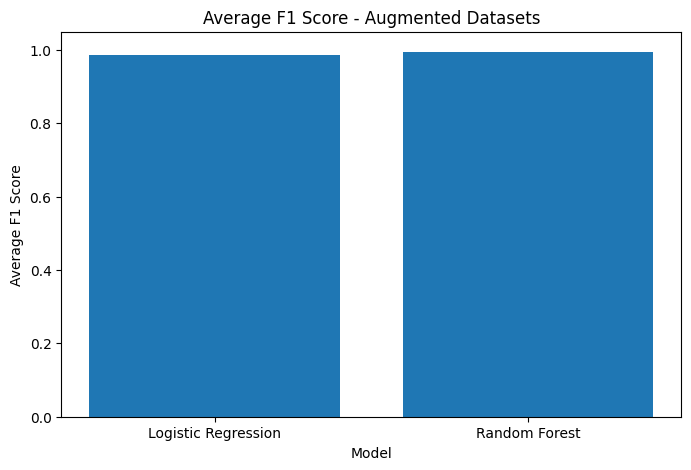

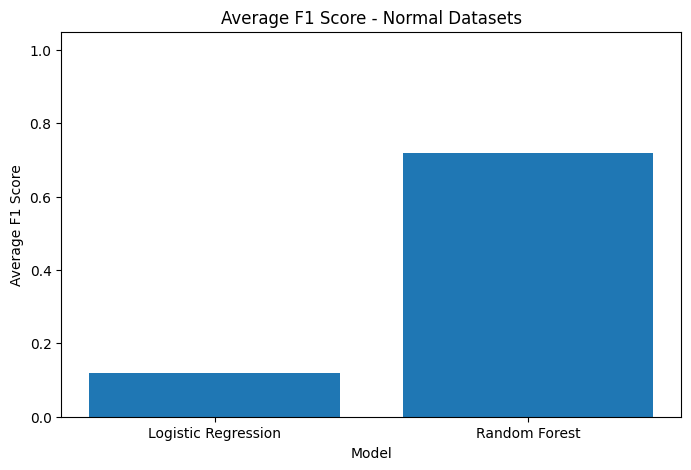

In [ ]:
# ********************************
# Visualization - Average F1 Score by model and dataset type
# ********************************

import matplotlib.pyplot as plt

f1_data = average_metrics.copy()

for dataset_type in f1_data["Dataset Type"].unique():
    subset = f1_data[f1_data["Dataset Type"] == dataset_type]

    plt.figure(figsize=(8, 5))
    plt.bar(subset["Model"], subset["F1 Score"])
    plt.title(f"Average F1 Score - {dataset_type} Datasets")
    plt.xlabel("Model")
    plt.ylabel("Average F1 Score")
    plt.ylim(0, 1.05)
    plt.show()

PR-AUC Bar graph

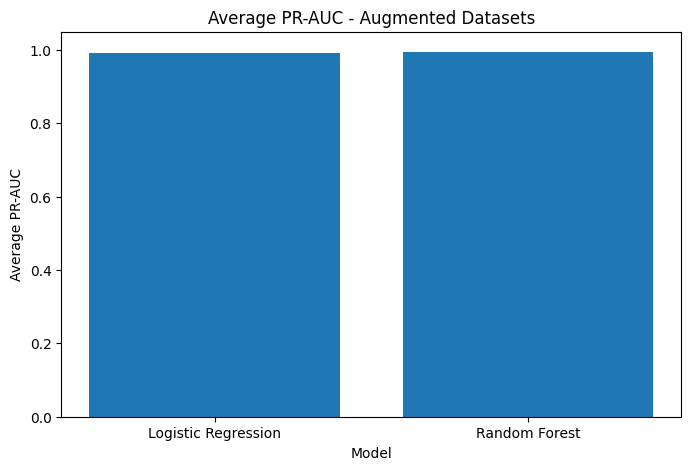

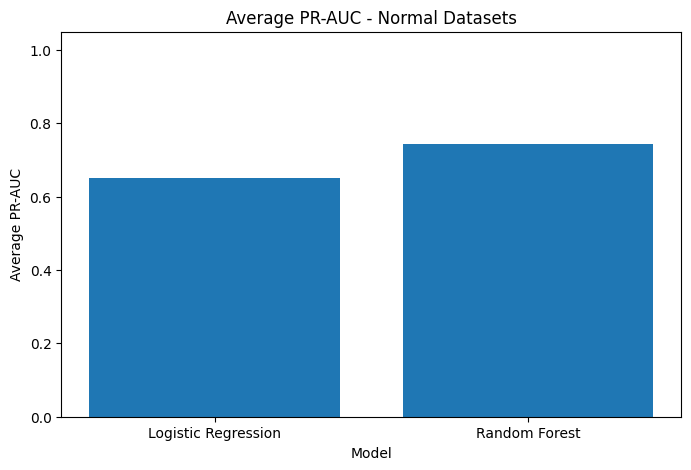

In [ ]:
# ********************************
# Visualization - Average PR-AUC by model and dataset type
# ********************************

pr_auc_data = average_metrics.copy()

for dataset_type in pr_auc_data["Dataset Type"].unique():
    subset = pr_auc_data[pr_auc_data["Dataset Type"] == dataset_type]

    plt.figure(figsize=(8, 5))
    plt.bar(subset["Model"], subset["PR-AUC"])
    plt.title(f"Average PR-AUC - {dataset_type} Datasets")
    plt.xlabel("Model")
    plt.ylabel("Average PR-AUC")
    plt.ylim(0, 1.05)
    plt.show()

All average metrics

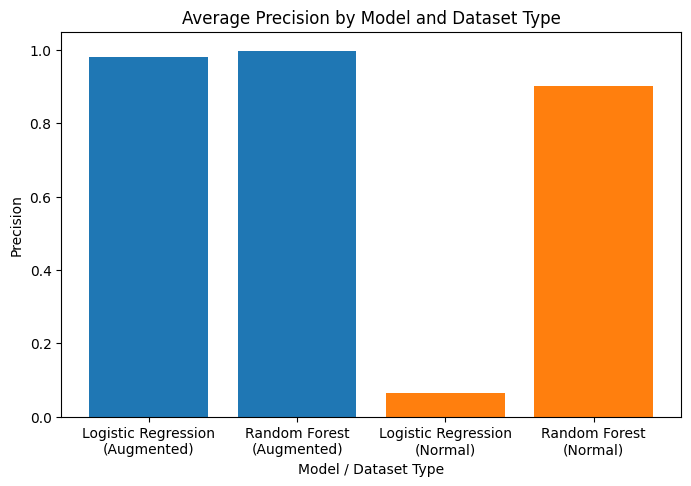

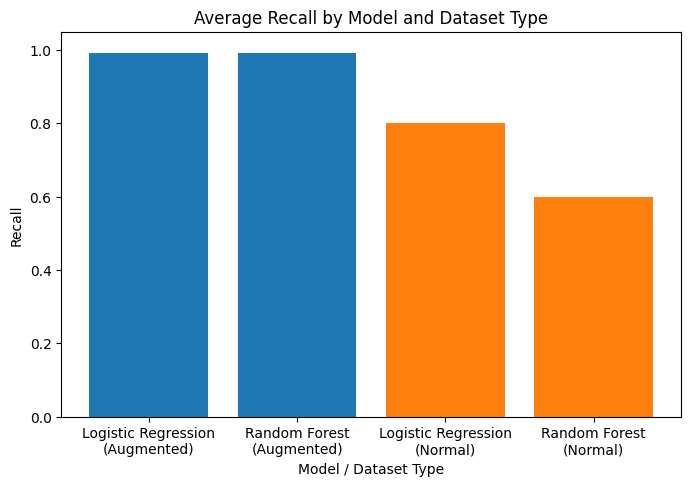

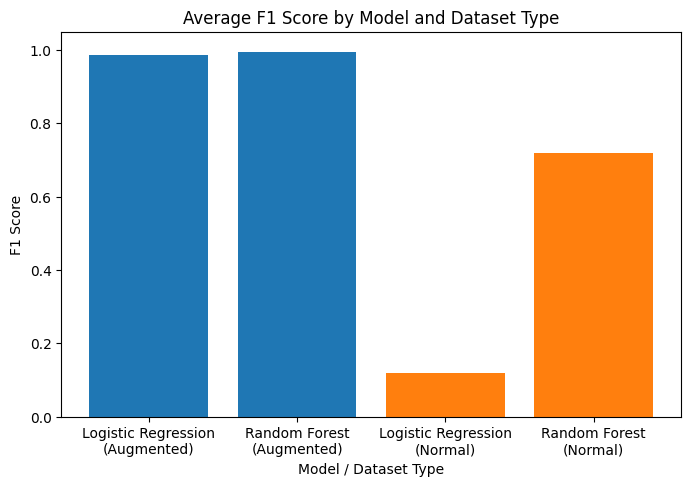

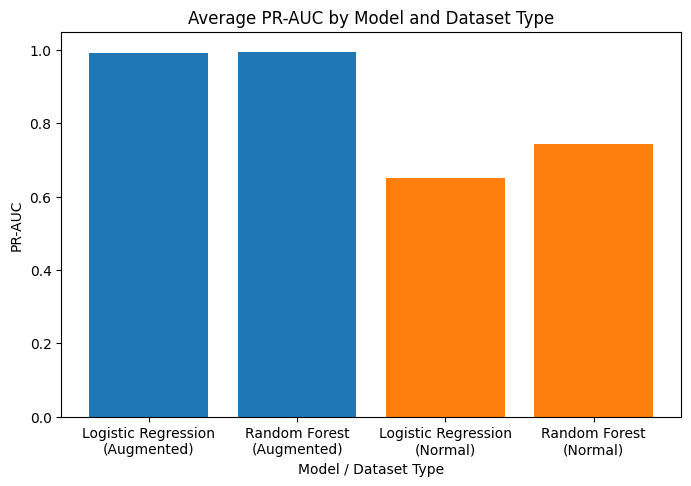

In [ ]:
# ********************************
# Visualization - All average metrics by model and dataset type
# ********************************

metrics = ["Precision", "Recall", "F1 Score", "PR-AUC"]

for metric in metrics:
    plt.figure(figsize=(8, 5))

    for dataset_type in average_metrics["Dataset Type"].unique():
        subset = average_metrics[average_metrics["Dataset Type"] == dataset_type]

        plt.bar(
            [f"{model}\n({dataset_type})" for model in subset["Model"]],
            subset[metric]
        )

    plt.title(f"Average {metric} by Model and Dataset Type")
    plt.xlabel("Model / Dataset Type")
    plt.ylabel(metric)
    plt.ylim(0, 1.05)
    plt.show()

comparison by bank

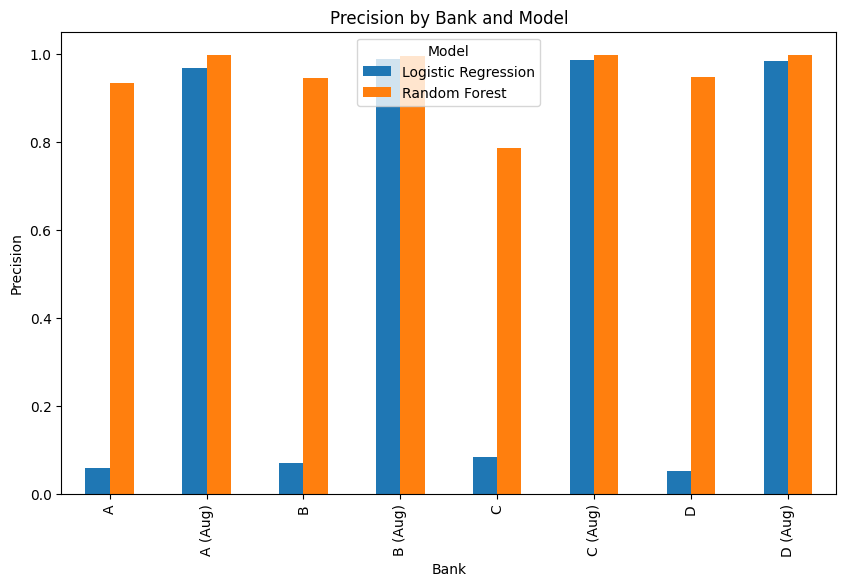

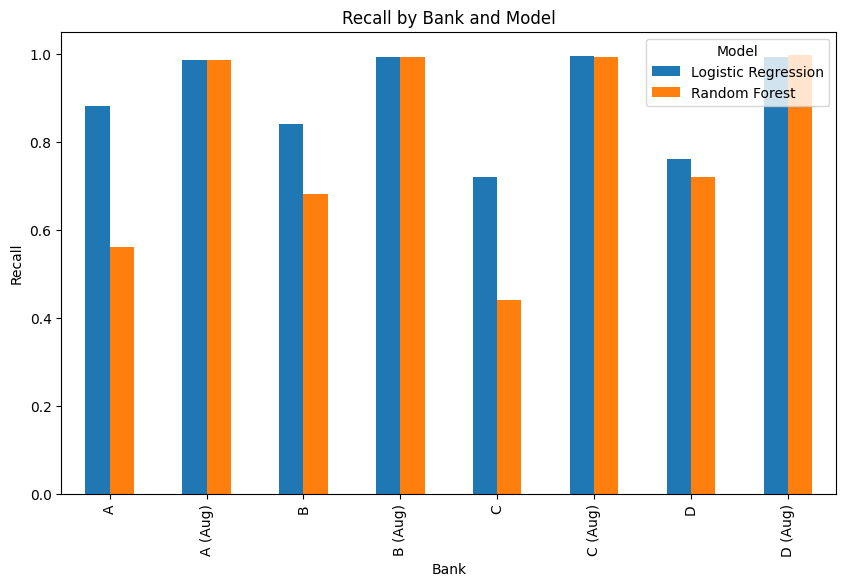

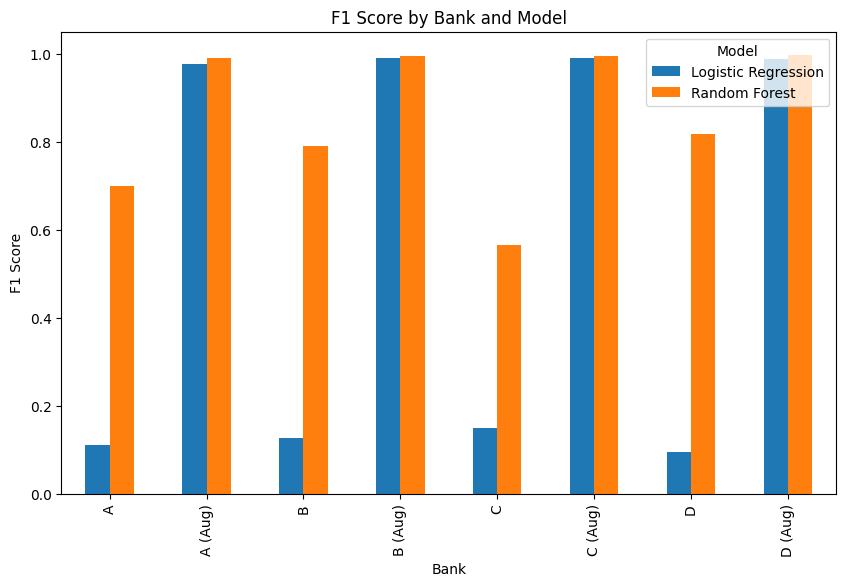

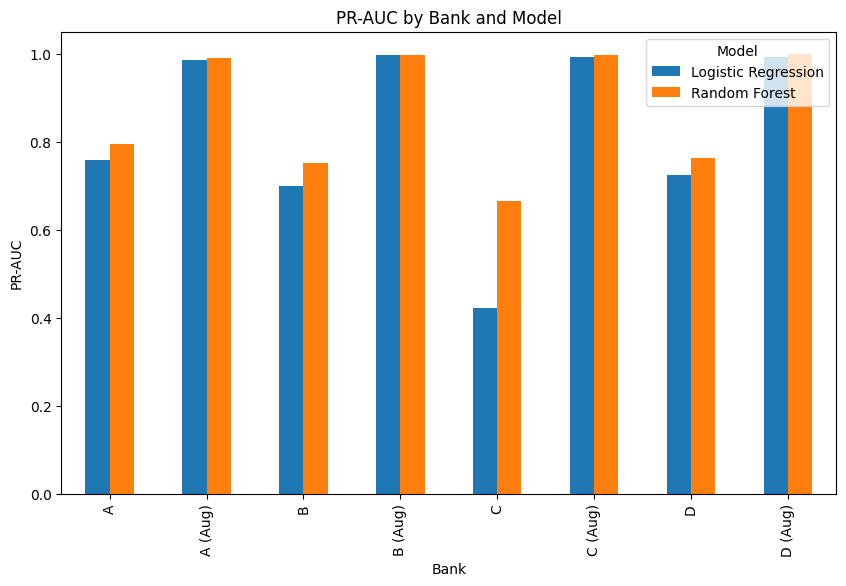

In [ ]:
# ********************************
# Visualization - Metric comparison by bank
# ********************************

metrics = ["Precision", "Recall", "F1 Score", "PR-AUC"]

for metric in metrics:
    pivot_table = model_comparison.pivot(index="Bank", columns="Model", values=metric)

    pivot_table.plot(kind="bar", figsize=(10, 6))
    plt.title(f"{metric} by Bank and Model")
    plt.xlabel("Bank")
    plt.ylabel(metric)
    plt.ylim(0, 1.05)
    plt.show()

# **FRAUD VS NON-FRAUD COMPARISON**

                    Metric    Value
0       Total Transactions   284807
1  Legitimate Transactions   284315
2  Fraudulent Transactions      492
3         Fraud Percentage  0.1727%
4           Average Amount   $88.35
5            Median Amount   $22.00


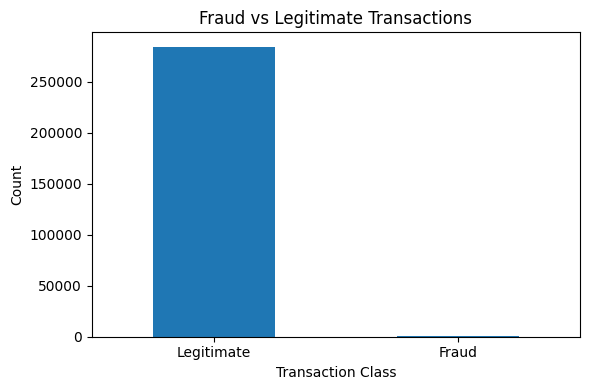

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_excel("creditcard.xlsx")

# Make sure Class is integer
df["Class"] = df["Class"].astype(int)

# Map labels for readability
df["ClassLabel"] = df["Class"].map({0: "Legitimate", 1: "Fraud"})

# -------------------------------
# Small summary data
# -------------------------------
class_counts = df["ClassLabel"].value_counts()
fraud_pct = df["Class"].mean() * 100

summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Legitimate Transactions",
        "Fraudulent Transactions",
        "Fraud Percentage",
        "Average Amount",
        "Median Amount"
    ],
    "Value": [
        len(df),
        (df["Class"] == 0).sum(),
        (df["Class"] == 1).sum(),
        f"{fraud_pct:.4f}%",
        f"${df['Amount'].mean():.2f}",
        f"${df['Amount'].median():.2f}"
    ]
})

print(summary)

# -------------------------------
# Chart 1: Class distribution
# -------------------------------
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300)
plt.show()

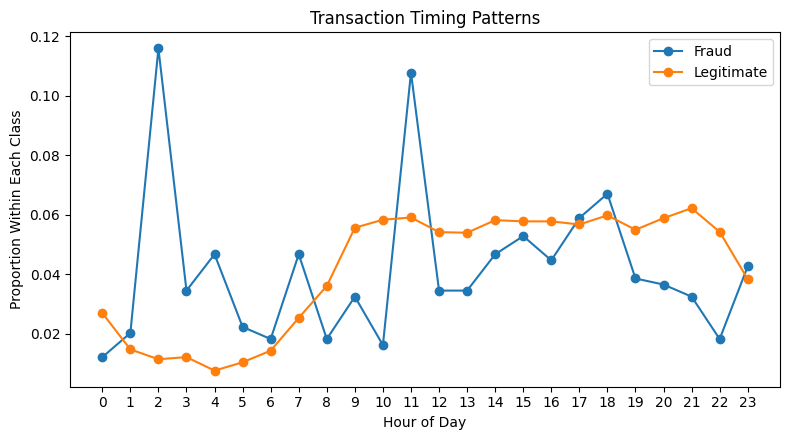

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("creditcard.xlsx")

# Make sure Class is integer
df["Class"] = df["Class"].astype(int)

# Map labels for readability
df["ClassLabel"] = df["Class"].map({0: "Legitimate", 1: "Fraud"})

# Convert Time (seconds) into 24-hour buckets
df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

# Count transactions by hour and class
hourly_counts = df.groupby(["Hour", "ClassLabel"]).size().unstack(fill_value=0)

# Force 0–23 hour order
hourly_counts = hourly_counts.reindex(range(24), fill_value=0)

# Normalize each class separately so both lines are visible
fraud_hourly = hourly_counts["Fraud"] / hourly_counts["Fraud"].sum()
legit_hourly = hourly_counts["Legitimate"] / hourly_counts["Legitimate"].sum()

# Plot
plt.figure(figsize=(8, 4.5))
plt.plot(fraud_hourly.index, fraud_hourly, marker="o", label="Fraud")
plt.plot(legit_hourly.index, legit_hourly, marker="o", label="Legitimate")

plt.title("Transaction Timing Patterns")
plt.xlabel("Hour of Day")
plt.ylabel("Proportion Within Each Class")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.savefig("timing_patterns_clean.png", dpi=300)
plt.show()

#  Model: Decision Tree

## Train Decision Tree

In [ ]:
# ************************************
# Train Decision Tree model for each bank
# ************************************

from sklearn.tree import DecisionTreeClassifier

dt_model_a = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_b = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_c = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_d = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_a_aug = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_b_aug = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_c_aug = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_d_aug = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

# DecisionTreeClassifier(...)
# Decision Tree --> model that makes predictions by following a series of yes/no style splits
# input = transaction features
# output = predicted fraud / non-fraud class
#
# random_state=42 --> makes results reproducible
#
# class_weight="balanced" --> tells model to give more importance to the minority class



# ---- Train the Decision Tree model on each bank's training data ----
dt_model_a.fit(X_a_train, y_a_train)
dt_model_b.fit(X_b_train, y_b_train)
dt_model_c.fit(X_c_train, y_c_train)
dt_model_d.fit(X_d_train, y_d_train)

dt_model_a_aug.fit(X_a_aug_train, y_a_aug_train)
dt_model_b_aug.fit(X_b_aug_train, y_b_aug_train)
dt_model_c_aug.fit(X_c_aug_train, y_c_aug_train)
dt_model_d_aug.fit(X_d_aug_train, y_d_aug_train)

# dt_model_a.fit --> use the training inputs 'X_a_train' & correct answers 'y_a_train,' to teach model patterns for banks

print("Decision Tree models trained successfully for normal and augmented Bank A, Bank B, Bank C, and Bank D.")

Decision Tree models trained successfully for normal and augmented Bank A, Bank B, Bank C, and Bank D.


## Predict and evaluate

In [ ]:
# ********************************
# Predict and evaluate Decision Tree
# ********************************

# ---- Generate class predictions for normal banks ----
dt_y_a_pred = dt_model_a.predict(X_a_test)
dt_y_b_pred = dt_model_b.predict(X_b_test)
dt_y_c_pred = dt_model_c.predict(X_c_test)
dt_y_d_pred = dt_model_d.predict(X_d_test)

# ---- Generate probability scores for normal banks ----
# predicted probabilities are used for PR-AUC
dt_y_a_scores = dt_model_a.predict_proba(X_a_test)[:, 1]
dt_y_b_scores = dt_model_b.predict_proba(X_b_test)[:, 1]
dt_y_c_scores = dt_model_c.predict_proba(X_c_test)[:, 1]
dt_y_d_scores = dt_model_d.predict_proba(X_d_test)[:, 1]

# ---- Generate class predictions for augmented banks ----
dt_y_a_aug_pred = dt_model_a_aug.predict(X_a_aug_test)
dt_y_b_aug_pred = dt_model_b_aug.predict(X_b_aug_test)
dt_y_c_aug_pred = dt_model_c_aug.predict(X_c_aug_test)
dt_y_d_aug_pred = dt_model_d_aug.predict(X_d_aug_test)

# ---- Generate probability scores for augmented banks ----
# predicted probabilities are used for PR-AUC
dt_y_a_aug_scores = dt_model_a_aug.predict_proba(X_a_aug_test)[:, 1]
dt_y_b_aug_scores = dt_model_b_aug.predict_proba(X_b_aug_test)[:, 1]
dt_y_c_aug_scores = dt_model_c_aug.predict_proba(X_c_aug_test)[:, 1]
dt_y_d_aug_scores = dt_model_d_aug.predict_proba(X_d_aug_test)[:, 1]

## Record results

In [ ]:
# ********************************
# Record Decision Tree results
# ********************************

dt_results = pd.DataFrame({
    "Bank": [
        "A", "B", "C", "D",
        "A (Aug)", "B (Aug)", "C (Aug)", "D (Aug)"
    ],
    "Precision": [
        precision_score(y_a_test, dt_y_a_pred, zero_division=0),
        precision_score(y_b_test, dt_y_b_pred, zero_division=0),
        precision_score(y_c_test, dt_y_c_pred, zero_division=0),
        precision_score(y_d_test, dt_y_d_pred, zero_division=0),
        precision_score(y_a_aug_test, dt_y_a_aug_pred, zero_division=0),
        precision_score(y_b_aug_test, dt_y_b_aug_pred, zero_division=0),
        precision_score(y_c_aug_test, dt_y_c_aug_pred, zero_division=0),
        precision_score(y_d_aug_test, dt_y_d_aug_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_a_test, dt_y_a_pred, zero_division=0),
        recall_score(y_b_test, dt_y_b_pred, zero_division=0),
        recall_score(y_c_test, dt_y_c_pred, zero_division=0),
        recall_score(y_d_test, dt_y_d_pred, zero_division=0),
        recall_score(y_a_aug_test, dt_y_a_aug_pred, zero_division=0),
        recall_score(y_b_aug_test, dt_y_b_aug_pred, zero_division=0),
        recall_score(y_c_aug_test, dt_y_c_aug_pred, zero_division=0),
        recall_score(y_d_aug_test, dt_y_d_aug_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_a_test, dt_y_a_pred, zero_division=0),
        f1_score(y_b_test, dt_y_b_pred, zero_division=0),
        f1_score(y_c_test, dt_y_c_pred, zero_division=0),
        f1_score(y_d_test, dt_y_d_pred, zero_division=0),
        f1_score(y_a_aug_test, dt_y_a_aug_pred, zero_division=0),
        f1_score(y_b_aug_test, dt_y_b_aug_pred, zero_division=0),
        f1_score(y_c_aug_test, dt_y_c_aug_pred, zero_division=0),
        f1_score(y_d_aug_test, dt_y_d_aug_pred, zero_division=0)
    ],
    "PR-AUC": [
        average_precision_score(y_a_test, dt_y_a_scores),
        average_precision_score(y_b_test, dt_y_b_scores),
        average_precision_score(y_c_test, dt_y_c_scores),
        average_precision_score(y_d_test, dt_y_d_scores),
        average_precision_score(y_a_aug_test, dt_y_a_aug_scores),
        average_precision_score(y_b_aug_test, dt_y_b_aug_scores),
        average_precision_score(y_c_aug_test, dt_y_c_aug_scores),
        average_precision_score(y_d_aug_test, dt_y_d_aug_scores)
    ]
})

dt_results

,Bank,Precision,Recall,F1 Score,PR-AUC
0,A,0.800000,0.480000,0.600000,0.384913
1,B,0.800000,0.640000,0.711111,0.512632
2,C,0.684211,0.520000,0.590909,0.356632
3,D,0.695652,0.640000,0.666667,0.445849
4,A (Aug),0.988304,0.949438,0.968481,0.940745
5,B (Aug),0.969274,0.974719,0.971989,0.945975
6,C (Aug),0.980029,0.964888,0.972399,0.947292
7,D (Aug),0.977401,0.971910,0.974648,0.951286


## Save results

In [ ]:
# ********************************
# Save Decision Tree results
# ********************************

# dt_results.to_csv("decision_tree_results.csv", index=False)

# print("Results file saved as decision_tree_results.csv")

#  Model: Gradient Boosting

## Train Gradient Boosting

In [ ]:
# ************************************
# Train Gradient Boosting model for each bank
# ************************************

from sklearn.ensemble import GradientBoostingClassifier

gb_model_a = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model_b = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model_c = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model_d = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model_a_aug = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model_b_aug = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model_c_aug = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model_d_aug = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# GradientBoostingClassifier(...)
# Gradient Boosting --> model that builds many small trees in sequence, where each new tree tries to improve the errors from the previous trees
# input = transaction features
# output = predicted fraud / non-fraud class
#
# n_estimators=100 --> uses 100 boosting stages
#
# learning_rate=0.1 --> controls how strongly each stage updates the model
#
# random_state=42 --> makes results reproducible



# ---- Train the Gradient Boosting model on each bank's training data ----
gb_model_a.fit(X_a_train, y_a_train)
gb_model_b.fit(X_b_train, y_b_train)
gb_model_c.fit(X_c_train, y_c_train)
gb_model_d.fit(X_d_train, y_d_train)

gb_model_a_aug.fit(X_a_aug_train, y_a_aug_train)
gb_model_b_aug.fit(X_b_aug_train, y_b_aug_train)
gb_model_c_aug.fit(X_c_aug_train, y_c_aug_train)
gb_model_d_aug.fit(X_d_aug_train, y_d_aug_train)

# gb_model_a.fit --> use the training inputs 'X_a_train' & correct answers 'y_a_train,' to teach model patterns for banks

print("Gradient Boosting models trained successfully for normal and augmented Bank A, Bank B, Bank C, and Bank D.")

Gradient Boosting models trained successfully for normal and augmented Bank A, Bank B, Bank C, and Bank D.


## Predict and evaluate

In [ ]:
# ********************************
# Predict and evaluate Gradient Boosting
# ********************************

# ---- Generate class predictions for normal banks ----
gb_y_a_pred = gb_model_a.predict(X_a_test)
gb_y_b_pred = gb_model_b.predict(X_b_test)
gb_y_c_pred = gb_model_c.predict(X_c_test)
gb_y_d_pred = gb_model_d.predict(X_d_test)

# ---- Generate probability scores for normal banks ----
# predicted probabilities are used for PR-AUC
gb_y_a_scores = gb_model_a.predict_proba(X_a_test)[:, 1]
gb_y_b_scores = gb_model_b.predict_proba(X_b_test)[:, 1]
gb_y_c_scores = gb_model_c.predict_proba(X_c_test)[:, 1]
gb_y_d_scores = gb_model_d.predict_proba(X_d_test)[:, 1]

# ---- Generate class predictions for augmented banks ----
gb_y_a_aug_pred = gb_model_a_aug.predict(X_a_aug_test)
gb_y_b_aug_pred = gb_model_b_aug.predict(X_b_aug_test)
gb_y_c_aug_pred = gb_model_c_aug.predict(X_c_aug_test)
gb_y_d_aug_pred = gb_model_d_aug.predict(X_d_aug_test)

# ---- Generate probability scores for augmented banks ----
# predicted probabilities are used for PR-AUC
gb_y_a_aug_scores = gb_model_a_aug.predict_proba(X_a_aug_test)[:, 1]
gb_y_b_aug_scores = gb_model_b_aug.predict_proba(X_b_aug_test)[:, 1]
gb_y_c_aug_scores = gb_model_c_aug.predict_proba(X_c_aug_test)[:, 1]
gb_y_d_aug_scores = gb_model_d_aug.predict_proba(X_d_aug_test)[:, 1]

## Record results

In [ ]:
# ********************************
# Record Gradient Boosting results
# ********************************

gb_results = pd.DataFrame({
    "Bank": [
        "A", "B", "C", "D",
        "A (Aug)", "B (Aug)", "C (Aug)", "D (Aug)"
    ],
    "Precision": [
        precision_score(y_a_test, gb_y_a_pred, zero_division=0),
        precision_score(y_b_test, gb_y_b_pred, zero_division=0),
        precision_score(y_c_test, gb_y_c_pred, zero_division=0),
        precision_score(y_d_test, gb_y_d_pred, zero_division=0),
        precision_score(y_a_aug_test, gb_y_a_aug_pred, zero_division=0),
        precision_score(y_b_aug_test, gb_y_b_aug_pred, zero_division=0),
        precision_score(y_c_aug_test, gb_y_c_aug_pred, zero_division=0),
        precision_score(y_d_aug_test, gb_y_d_aug_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_a_test, gb_y_a_pred, zero_division=0),
        recall_score(y_b_test, gb_y_b_pred, zero_division=0),
        recall_score(y_c_test, gb_y_c_pred, zero_division=0),
        recall_score(y_d_test, gb_y_d_pred, zero_division=0),
        recall_score(y_a_aug_test, gb_y_a_aug_pred, zero_division=0),
        recall_score(y_b_aug_test, gb_y_b_aug_pred, zero_division=0),
        recall_score(y_c_aug_test, gb_y_c_aug_pred, zero_division=0),
        recall_score(y_d_aug_test, gb_y_d_aug_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_a_test, gb_y_a_pred, zero_division=0),
        f1_score(y_b_test, gb_y_b_pred, zero_division=0),
        f1_score(y_c_test, gb_y_c_pred, zero_division=0),
        f1_score(y_d_test, gb_y_d_pred, zero_division=0),
        f1_score(y_a_aug_test, gb_y_a_aug_pred, zero_division=0),
        f1_score(y_b_aug_test, gb_y_b_aug_pred, zero_division=0),
        f1_score(y_c_aug_test, gb_y_c_aug_pred, zero_division=0),
        f1_score(y_d_aug_test, gb_y_d_aug_pred, zero_division=0)
    ],
    "PR-AUC": [
        average_precision_score(y_a_test, gb_y_a_scores),
        average_precision_score(y_b_test, gb_y_b_scores),
        average_precision_score(y_c_test, gb_y_c_scores),
        average_precision_score(y_d_test, gb_y_d_scores),
        average_precision_score(y_a_aug_test, gb_y_a_aug_scores),
        average_precision_score(y_b_aug_test, gb_y_b_aug_scores),
        average_precision_score(y_c_aug_test, gb_y_c_aug_scores),
        average_precision_score(y_d_aug_test, gb_y_d_aug_scores)
    ]
})

gb_results

,Bank,Precision,Recall,F1 Score,PR-AUC
0,A,0.684211,0.520000,0.590909,0.522820
1,B,0.681818,0.600000,0.638298,0.591972
2,C,0.800000,0.640000,0.711111,0.521332
3,D,0.800000,0.640000,0.711111,0.574895
4,A (Aug),0.990043,0.977528,0.983746,0.981204
5,B (Aug),0.994374,0.992978,0.993675,0.997441
6,C (Aug),0.994374,0.992978,0.993675,0.988253
7,D (Aug),0.984701,0.994382,0.989518,0.958883


## Save results

In [ ]:
# ********************************
# Save Gradient Boosting results
# ********************************

# gb_results.to_csv("gradient_boosting_results.csv", index=False)

# print("Results file saved as gradient_boosting_results.csv")

# ALL MODEL COMPARISONS

## FRAUD VS NON-FRAUD

In [ ]:
# ********************************
# Compare all models
# ********************************

results["Model"] = "Logistic Regression"
rf_results["Model"] = "Random Forest"
dt_results["Model"] = "Decision Tree"
gb_results["Model"] = "Gradient Boosting"

all_model_comparison = pd.concat(
    [results, rf_results, dt_results, gb_results],
    ignore_index=True
)

all_model_comparison

,Bank,Precision,Recall,F1 Score,PR-AUC,Model
0,A,0.058355,0.880000,0.109453,0.757413,Logistic Regression
1,B,0.068404,0.840000,0.126506,0.699176,Logistic Regression
2,C,0.083333,0.720000,0.149378,0.421169,Logistic Regression
3,D,0.050398,0.760000,0.094527,0.723175,Logistic Regression
4,A (Aug),0.966897,0.984551,0.975644,0.986102,Logistic Regression
5,B (Aug),0.987430,0.992978,0.990196,0.996847,Logistic Regression
6,C (Aug),0.984701,0.994382,0.989518,0.992631,Logistic Regression
7,D (Aug),0.983287,0.991573,0.987413,0.991229,Logistic Regression
8,A,0.933333,0.560000,0.700000,0.794935,Random Forest
9,B,0.944444,0.680000,0.790698,0.750617,Random Forest


## Bar graphs

In [ ]:
# ********************************
# Average metrics by model and dataset type
# ********************************

# ---- Create dataset type column ----
# Normal --> original bank files
# Augmented --> augmented bank files

all_model_comparison["Dataset Type"] = all_model_comparison["Bank"].apply(
    lambda x: "Augmented" if "(Aug)" in x else "Normal"
)

# ---- Group by model and dataset type, then calculate average metrics ----
average_metrics_all = all_model_comparison.groupby(["Model", "Dataset Type"])[
    ["Precision", "Recall", "F1 Score", "PR-AUC"]
].mean().reset_index()

average_metrics_all

,Model,Dataset Type,Precision,Recall,F1 Score,PR-AUC
0,Decision Tree,Augmented,0.978752,0.965239,0.971879,0.946325
1,Decision Tree,Normal,0.744966,0.570000,0.642172,0.425007
2,Gradient Boosting,Augmented,0.990873,0.989466,0.990154,0.981445
3,Gradient Boosting,Normal,0.741507,0.600000,0.662857,0.552755
4,Logistic Regression,Augmented,0.980579,0.990871,0.985693,0.991702
5,Logistic Regression,Normal,0.065123,0.800000,0.119966,0.650233
6,Random Forest,Augmented,0.995773,0.991573,0.993662,0.995281
7,Random Forest,Normal,0.902715,0.600000,0.718246,0.743272


                 Model Dataset Type  Precision    Recall  F1 Score    PR-AUC
0        Decision Tree    Augmented   0.978752  0.965239  0.971879  0.946325
1        Decision Tree       Normal   0.744966  0.570000  0.642172  0.425007
2    Gradient Boosting    Augmented   0.990873  0.989466  0.990154  0.981445
3    Gradient Boosting       Normal   0.741507  0.600000  0.662857  0.552755
4  Logistic Regression    Augmented   0.980579  0.990871  0.985693  0.991702
5  Logistic Regression       Normal   0.065123  0.800000  0.119966  0.650233
6        Random Forest    Augmented   0.995773  0.991573  0.993662  0.995281
7        Random Forest       Normal   0.902715  0.600000  0.718246  0.743272


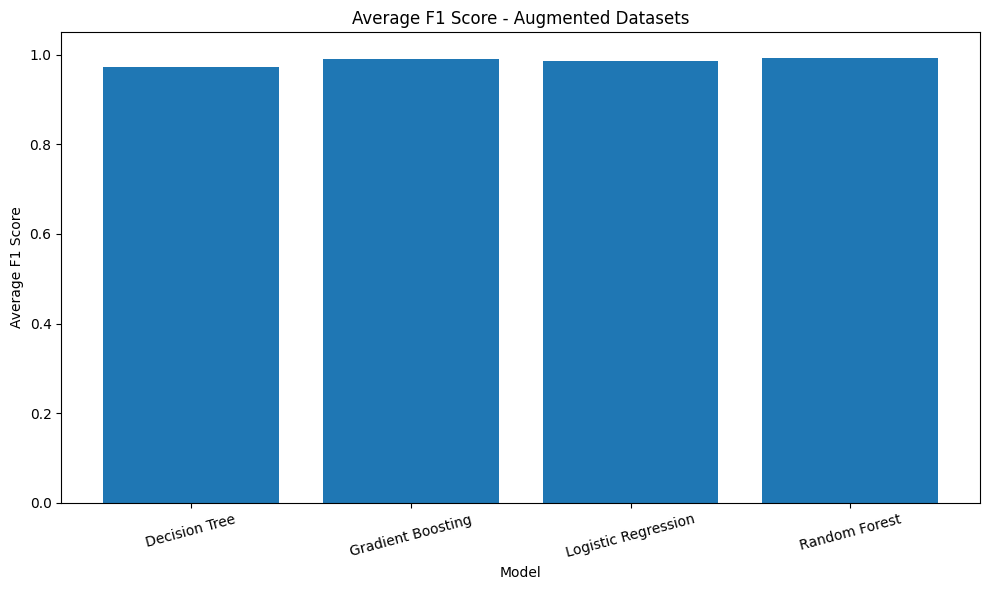

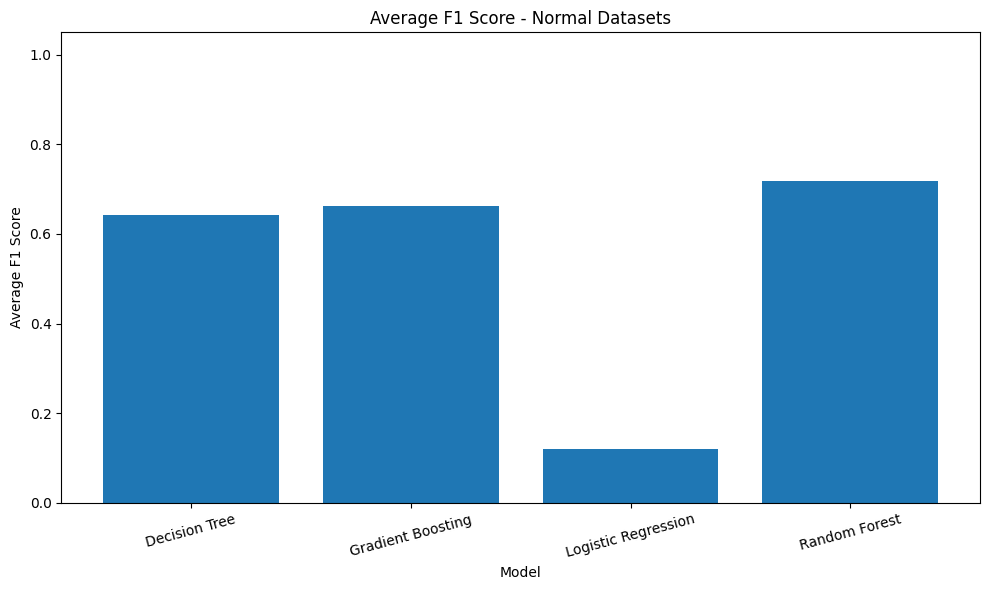

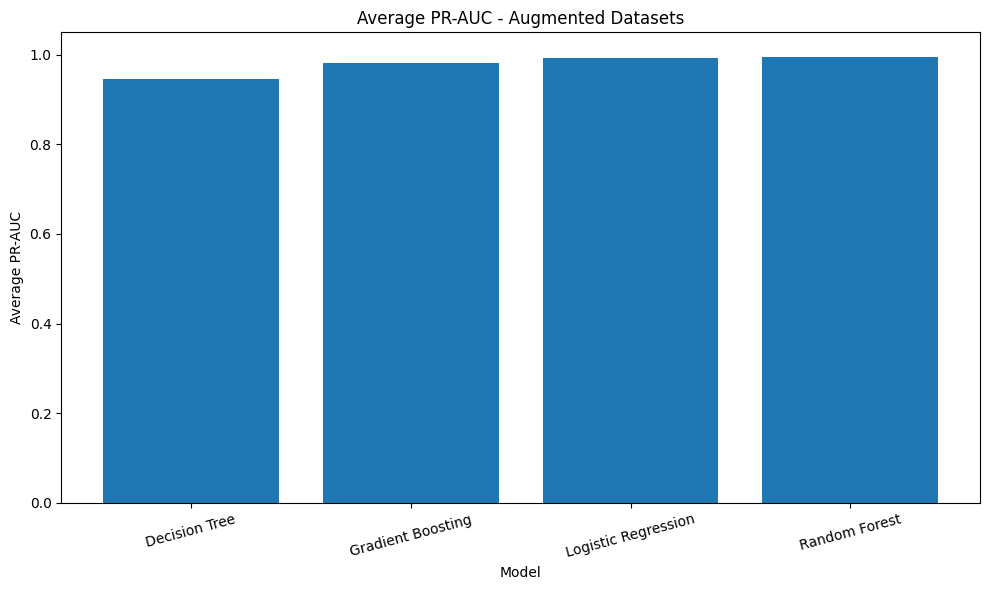

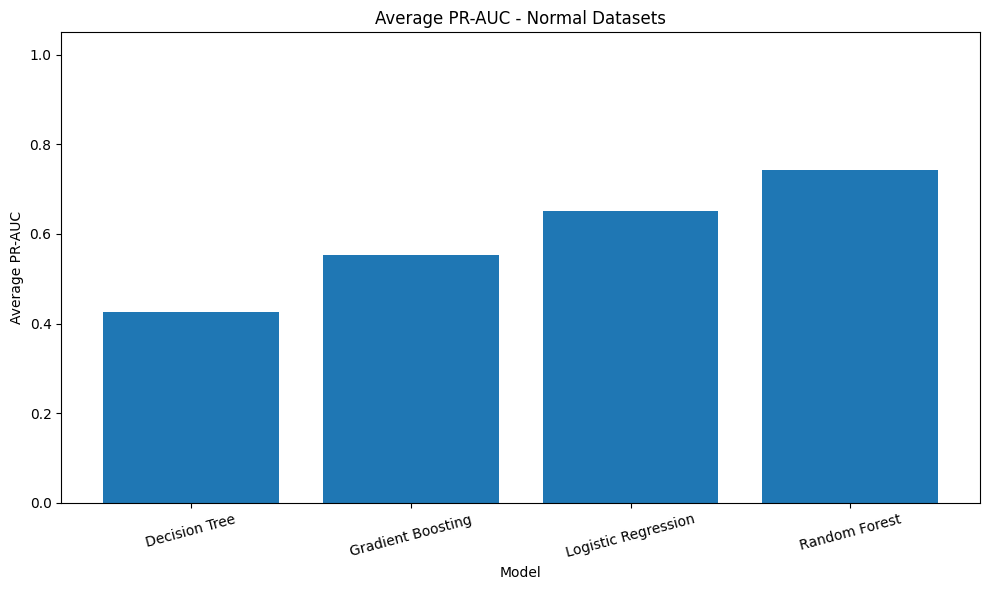

In [ ]:
# ********************************
# Bar graphs - Average F1 Score and PR-AUC by model and dataset type
# ********************************

import matplotlib.pyplot as plt

# ---- Make sure average_metrics_all exists ----
print(average_metrics_all)

metrics_to_graph = ["F1 Score", "PR-AUC"]

for metric in metrics_to_graph:
    for dataset_type in average_metrics_all["Dataset Type"].unique():
        subset = average_metrics_all[average_metrics_all["Dataset Type"] == dataset_type]

        plt.figure(figsize=(10, 6))
        plt.bar(subset["Model"], subset[metric])
        plt.title(f"Average {metric} - {dataset_type} Datasets")
        plt.xlabel("Model")
        plt.ylabel(f"Average {metric}")
        plt.ylim(0, 1.05)
        plt.xticks(rotation=15)
        plt.tight_layout()
        plt.show()

# Data Integrity - SHA-256 Hashing

***Why this matters:*** Fraud detection pipelines work with sensitive financial data and produce results that downstream teams rely on. If a dataset or a results file is silently modified, model evaluations can no longer be trusted.

***What it does:*** This section computes a SHA-256 hash (a unique "fingerprint") for each input dataset and each model results table. Even a single changed byte produces a completely different hash, so re-running the check later quickly reveals whether any file has been tampered with.

***How to use it:*** Record the hashes when the pipeline first runs. Re-run the verification cell later to confirm that the files still match their original fingerprints.

## Significance of the hash

***Tamper-evidence:*** Even a one-byte change to a dataset, results file, or trained model produces a completely different SHA-256 value, so any after-the-fact modification is immediately visible when the hash is re-checked.

***Model integrity:*** Every fitted estimator (all 32 trained objects across Logistic Regression, Random Forest, Decision Tree, and Gradient Boosting) is serialized with a fixed pickle protocol and hashed. This detects not just data tampering but also silent swaps of the model weights themselves.

***Master hash:*** A single "hash of hashes" is computed over every individual fingerprint. Publishing or signing this one value is enough to lock down the entire run — any change to any input, result, or model will break it.

***Reproducibility:*** Storing the hash alongside a result confirms that anyone re-running the notebook is working from the exact same inputs. If the hashes no longer match, the data has drifted and the numbers cannot be compared like-for-like.

***Auditability:*** Regulators and internal risk teams often need a cryptographic paper trail for financial models. Recording the SHA-256 of each input, output, and fitted model — along with a UTC run timestamp and pinned Python / scikit-learn versions — gives a lightweight audit record without exposing any sensitive content.

***One-way function:*** SHA-256 cannot be reversed back into the original data, so the hash itself is safe to share, email, or commit to version control even when the underlying transactions or model weights are confidential.

***Collision resistance:*** SHA-256 is considered computationally infeasible to forge — it is not realistically possible to craft a different file, DataFrame, or model that produces the same hash, which is what makes the fingerprint trustworthy as evidence.

## Compute SHA-256 hashes

In [ ]:
# ********************************
# Compute SHA-256 hashes
# ********************************

import hashlib
import pickle
import sys
import sklearn
from datetime import datetime, timezone

import pandas as pd

# ---- Helper: hash a file on disk in chunks ----
# Reads the file in 64KB chunks so large CSVs don't have to fit in memory
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()

# ---- Helper: hash a DataFrame's contents ----
# Uses a deterministic CSV representation so the same DataFrame always produces the same hash
def sha256_dataframe(df):
    data = df.to_csv(index=False).encode("utf-8")
    return hashlib.sha256(data).hexdigest()

# ---- Helper: hash a fitted model object ----
# Serializes the trained estimator with a fixed pickle protocol
# so the same model always produces the same hash
def sha256_model(model):
    data = pickle.dumps(model, protocol=4)
    return hashlib.sha256(data).hexdigest()

# ---- Helper: chain individual hashes into one master hash ----
# Produces a single "fingerprint of fingerprints" that changes if ANY item changes
def sha256_master(hash_dict):
    joined = "\n".join(f"{k}:{v}" for k, v in sorted(hash_dict.items()))
    return hashlib.sha256(joined.encode("utf-8")).hexdigest()

# ---- Record run metadata ----
# UTC timestamp + library versions are pinned so environment drift is visible
run_timestamp = datetime.now(timezone.utc).isoformat(timespec="seconds")
env_info = f"python={sys.version.split()[0]};sklearn={sklearn.__version__}"
env_hash = hashlib.sha256(env_info.encode("utf-8")).hexdigest()

# ---- Hash input dataset files ----
input_files = [
    "bank_a.csv",
    "bank_b.csv",
    "bank_c.csv",
    "bank_d.csv",
    "bank_a(augmented).csv",
    "bank_b(augmented).csv",
    "bank_c(augmented).csv",
    "bank_d(augmented).csv",
    "creditcard.xlsx"
]

input_hashes = {name: sha256_file(name) for name in input_files}

# ---- Hash model results tables ----
result_hashes = {
    "logistic_regression_results": sha256_dataframe(results),
    "random_forest_results": sha256_dataframe(rf_results),
    "decision_tree_results": sha256_dataframe(dt_results),
    "gradient_boosting_results": sha256_dataframe(gb_results),
    "all_model_comparison": sha256_dataframe(all_model_comparison)
}

# ---- Hash every fitted model object ----
# All 32 trained estimators: 4 algorithms x 4 banks x (normal + augmented)
fitted_models = {
    # Logistic Regression
    "model_a": model_a,
    "model_b": model_b,
    "model_c": model_c,
    "model_d": model_d,
    "model_a_aug": model_a_aug,
    "model_b_aug": model_b_aug,
    "model_c_aug": model_c_aug,
    "model_d_aug": model_d_aug,
    # Random Forest
    "rf_model_a": rf_model_a,
    "rf_model_b": rf_model_b,
    "rf_model_c": rf_model_c,
    "rf_model_d": rf_model_d,
    "rf_model_a_aug": rf_model_a_aug,
    "rf_model_b_aug": rf_model_b_aug,
    "rf_model_c_aug": rf_model_c_aug,
    "rf_model_d_aug": rf_model_d_aug,
    # Decision Tree
    "dt_model_a": dt_model_a,
    "dt_model_b": dt_model_b,
    "dt_model_c": dt_model_c,
    "dt_model_d": dt_model_d,
    "dt_model_a_aug": dt_model_a_aug,
    "dt_model_b_aug": dt_model_b_aug,
    "dt_model_c_aug": dt_model_c_aug,
    "dt_model_d_aug": dt_model_d_aug,
    # Gradient Boosting
    "gb_model_a": gb_model_a,
    "gb_model_b": gb_model_b,
    "gb_model_c": gb_model_c,
    "gb_model_d": gb_model_d,
    "gb_model_a_aug": gb_model_a_aug,
    "gb_model_b_aug": gb_model_b_aug,
    "gb_model_c_aug": gb_model_c_aug,
    "gb_model_d_aug": gb_model_d_aug
}

model_hashes = {name: sha256_model(obj) for name, obj in fitted_models.items()}

# ---- Compute master hash over every individual fingerprint ----
# One value that changes if ANY input, result, model, or env string is modified
all_hashes = {
    **input_hashes,
    **result_hashes,
    **model_hashes,
    "environment": env_hash
}
master_hash = sha256_master(all_hashes)

# ---- Build a combined manifest ----
manifest_rows = (
    [{"Item": name, "Type": "Input File", "SHA-256": h} for name, h in input_hashes.items()]
    + [{"Item": name, "Type": "Results Table", "SHA-256": h} for name, h in result_hashes.items()]
    + [{"Item": name, "Type": "Fitted Model", "SHA-256": h} for name, h in model_hashes.items()]
    + [{"Item": "environment", "Type": "Run Environment", "SHA-256": env_hash}]
    + [{"Item": "MASTER", "Type": "Master Hash", "SHA-256": master_hash}]
)

hash_manifest = pd.DataFrame(manifest_rows)
hash_manifest["Run Timestamp (UTC)"] = run_timestamp

# ---- Print a short summary ----
print(f"Computed SHA-256 hashes for {len(hash_manifest) - 1} items (+ 1 master hash).")
print(f"Environment: {env_info}")
print(f"Run timestamp (UTC): {run_timestamp}")
print(f"Master hash: {master_hash}")

hash_manifest

## Save hash manifest

In [ ]:
# ********************************
# Save hash manifest
# ********************************

# hash_manifest.to_csv("integrity_manifest.csv", index=False)

# print("Hash manifest saved as integrity_manifest.csv")

## Verify integrity

***Why this matters:*** A hash is only useful if it's actually checked. Re-computing hashes and comparing them against the saved manifest is what turns them into tamper-evidence.

***What it does:*** Recomputes the SHA-256 hash for each input file, results table, fitted model, and the run environment, then rebuilds the master hash and reports whether every value still matches what was recorded earlier. Any mismatch is flagged as `TAMPERED`.

In [ ]:
# ********************************
# Verify integrity against manifest
# ********************************

# ---- Recompute current hashes for input files ----
current_input_hashes = {name: sha256_file(name) for name in input_files}

# ---- Recompute current hashes for results tables ----
current_result_hashes = {
    "logistic_regression_results": sha256_dataframe(results),
    "random_forest_results": sha256_dataframe(rf_results),
    "decision_tree_results": sha256_dataframe(dt_results),
    "gradient_boosting_results": sha256_dataframe(gb_results),
    "all_model_comparison": sha256_dataframe(all_model_comparison)
}

# ---- Recompute current hashes for every fitted model ----
current_model_hashes = {name: sha256_model(obj) for name, obj in fitted_models.items()}

# ---- Recompute current environment hash and master hash ----
current_env_info = f"python={sys.version.split()[0]};sklearn={sklearn.__version__}"
current_env_hash = hashlib.sha256(current_env_info.encode("utf-8")).hexdigest()

current_all_hashes = {
    **current_input_hashes,
    **current_result_hashes,
    **current_model_hashes,
    "environment": current_env_hash
}
current_master_hash = sha256_master(current_all_hashes)

# ---- Compare against the original manifest ----
original = dict(zip(hash_manifest["Item"], hash_manifest["SHA-256"]))
current = {**current_all_hashes, "MASTER": current_master_hash}

verification = pd.DataFrame({
    "Item": list(current.keys()),
    "Original SHA-256": [original.get(name, "") for name in current],
    "Current SHA-256": list(current.values())
})

verification["Status"] = verification.apply(
    lambda row: "OK" if row["Original SHA-256"] == row["Current SHA-256"] else "TAMPERED",
    axis=1
)

# ---- Print a short summary ----
ok_count = (verification["Status"] == "OK").sum()
total = len(verification)
master_status = verification.loc[verification["Item"] == "MASTER", "Status"].iloc[0]
print(f"Integrity check: {ok_count}/{total} items match their original SHA-256 hash.")
print(f"Master hash status: {master_status}")

verification